# Libraries

In [1]:
# !pip install qiskit==2.4.1 qiskit-aer==0.17.2
# from getpass import getpass
# token = getpass("GitHub token: ")
# !git clone https://{token}@github.com/srazzetti/statistical-qst-vae.git
# %cd statistical-qst-vae/notebook

In [2]:
import tensorflow as tf
import keras
from keras.models import Sequential, save_model
from keras.layers import Conv1D, Conv1DTranspose, Dense, BatchNormalization, Activation, Input
from keras.constraints import max_norm
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import math
import sys
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
import sklearn
from sklearn.model_selection import train_test_split

In [3]:
sys.path.append('../src')
from povm_sampling import sample_povm, povm_probability_efficient, samples_to_onehot, samples_to_empirical_dist
from statesprep import create_ghz_state, create_w_state
from vae import *
from utils import classical_fidelity

# Data Creation and Processing

In [4]:
# Create a GHZ state and compute the corresponding density matrix
n_samples = 1000
n_qubits = 3
qc = create_ghz_state(n_qubits)
rho = DensityMatrix(qc)

# Compute the probability distribution over the outcomes of the POVM measurement and sample from it
prob = povm_probability_efficient(rho.data, n_qubits)
sample = sample_povm(prob, n_samples=n_samples)
P_empirical = samples_to_empirical_dist(sample, n_qubits)

# Convert the samples to one-hot encoding
onehot_sample = samples_to_onehot(sample, n_qubits)

In [5]:
# Split the data into training and testing sets (unsupervised: no labels, no stratify)
X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

print(f"Training set size and shape: {len(X_train)} and {X_train.shape}")
print(f"Testing set size and shape: {len(X_test)} and {X_test.shape}")

Training set size and shape: 800 and (800, 12)
Testing set size and shape: 200 and (200, 12)


# Train

In [8]:
# Define useful parameters for the VAE training
LATENT_DIM = 16
HIDDEN_DIM = 96
WARMUP_EPOCHS = 100
TOTAL_EPOCHS = 1000
BATCH_SIZE = 100
LEARNING_RATE = 1e-3
BETA_MAX = 0.85

In [9]:
# Instantiate and compile the VAE model
vae = VAE(n_qubits=n_qubits, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
vae.build(input_shape=(None, 4*n_qubits))
model = vae

In [10]:
# Compute the exact probability distribution over the POVM outcomes
P_exact = povm_probability_efficient(rho.data, n_qubits)

# Define callbacks for training
callbacks = [
    KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
    #FidelityMonitor(P_exact, n_qubits, n_gen=20000),
    EarlyStopping(monitor='val_loss', mode='min',
                  patience=60, restore_best_weights=True, 
                  start_from_epoch=WARMUP_EPOCHS),
    ReduceLROnPlateau(monitor='val_loss', mode='min',
                      factor=0.5, patience=20, min_lr=1e-6),
]

# fit data
history = model.fit(
    X_train, X_train,
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, X_test),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - kl_loss: 0.4249 - kl_weight: 0.0000e+00 - loss: 4.0977 - reconstruction_loss: 4.0977 - val_kl_loss: 0.4048 - val_loss: 4.1353 - val_reconstruction_loss: 4.1353 - learning_rate: 0.0010
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 0.7634 - kl_weight: 0.0085 - loss: 3.8565 - reconstruction_loss: 3.8501 - val_kl_loss: 0.7246 - val_loss: 3.9582 - val_reconstruction_loss: 3.9520 - learning_rate: 0.0010
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 1.5575 - kl_weight: 0.0170 - loss: 3.5189 - reconstruction_loss: 3.4924 - val_kl_loss: 1.4616 - val_loss: 3.7579 - val_reconstruction_loss: 3.7331 - learning_rate: 0.0010
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 2.9910 - kl_weight: 0.0255 - loss: 3.2265 - reconstruction_loss: 3.1502 - val_kl_loss: 3.0342 - val_loss: 3.2118 - val_reconstruction_loss: 3.1344 - learning_rate: 0.0010
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 5.7840

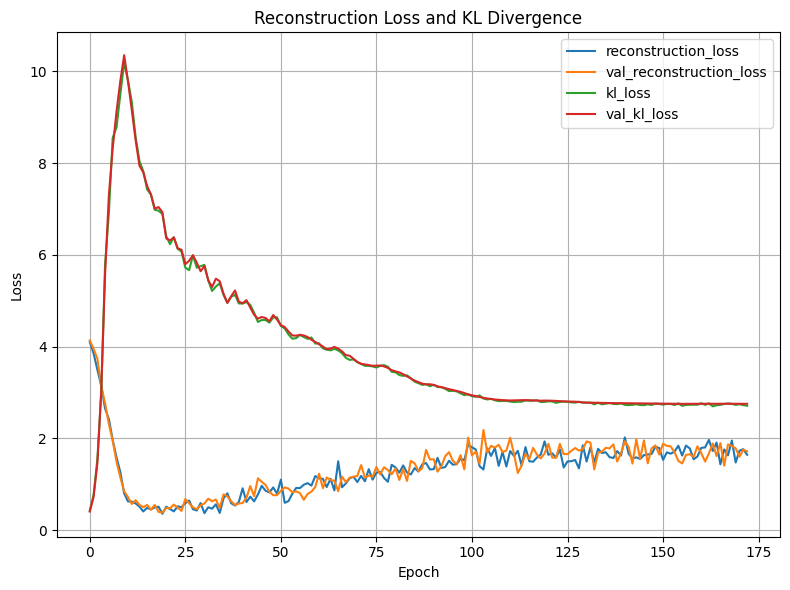

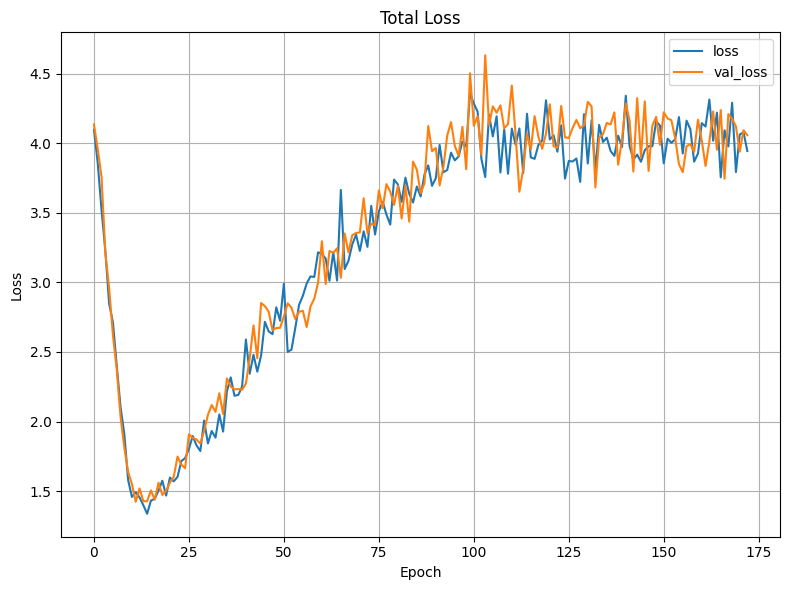

In [11]:
# Plot the training and validation loss curves
plot_reconstruction_and_kl_divergence(history)
plot_total_loss(history)

# Validation: distribuzione generata vs POVM vera

=== FIDELITY CLASSICA ===
  rumore uniforme  vs esatta : 0.9510   <- FLOOR
  VAE              vs esatta : 0.9814   <- MODELLO
  dati training    vs esatta : 0.9860   <- TETTO

=== I 4 PICCHI del GHZ ===
  outcome          esatta      VAE  uniforme
  (0, 0, 0)      0.0625000 0.0574710 0.0156250
  (1, 1, 1)      0.0339279 0.0190340 0.0156250
  (2, 2, 2)      0.0339279 0.0244210 0.0156250
  (3, 3, 3)      0.0339279 0.0201450 0.0156250


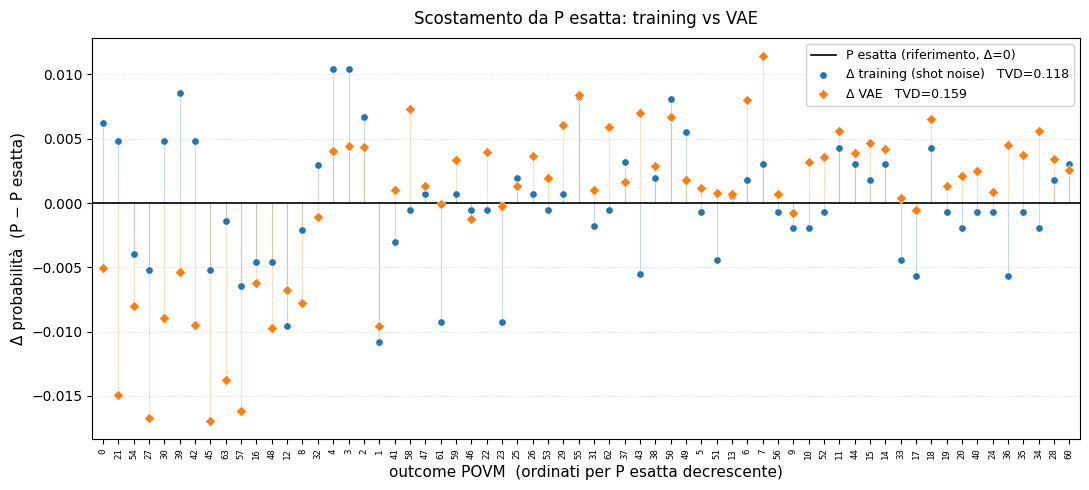

In [14]:
from povm_sampling import onehot_to_samples

# Calculate the exact probability distribution over the POVM outcomes (P_exact)
P_exact = povm_probability_efficient(rho.data, n_qubits)
outcomes = list(P_exact.keys())

# Generate a large number of samples from the trained VAE model to estimate the distribution it has learned (P_vae)
# Convert the one-hot encoded training data back to samples and compute the empirical distribution (P_train)
P_vae   = model.generate_empirical_dist(n_samples=1000000, batch_size=50_000)
P_unif = {o: 1.0 / len(outcomes) for o in outcomes}
P_train = samples_to_empirical_dist(onehot_to_samples(X_train, n_qubits), n_qubits)

# Compute the classical fidelity between the distributions
classical_fidelity_floor = classical_fidelity(P_unif, P_exact)
classical_fidelity_vae = classical_fidelity(P_vae, P_exact)
classical_fidelity_train = classical_fidelity(P_train, P_exact)

print("=== FIDELITY CLASSICA ===")
print(f"  rumore uniforme  vs esatta : {classical_fidelity_floor:.4f}   <- FLOOR")
print(f"  VAE              vs esatta : {classical_fidelity_vae:.4f}   <- MODELLO")
print(f"  dati training    vs esatta : {classical_fidelity_train:.4f}   <- TETTO\n")

print("=== I 4 PICCHI del GHZ ===")
print(f"  {'outcome':14s} {'esatta':>8s} {'VAE':>8s} {'uniforme':>9s}")
for o in [(c,) * n_qubits for c in range(4)]:
    print(f"  {str(o):14s} {P_exact[o]:8.7f} {P_vae.get(o, 0):8.7f} {1/len(outcomes):9.7f}")

# Plot the distributions (P_exact, P_vae, P_train) over the outcomes
p_true = np.array([P_exact[o]        for o in outcomes])
p_gen  = np.array([P_vae.get(o, 0.0) for o in outcomes]) 
p_train = np.array([P_train.get(o, 0.0) for o in outcomes])
idx = np.arange(len(outcomes))

plot_distribution_delta(p_true, p_gen, p_train, idx)


# Provo da 3 a 8 qubit

In [ ]:
from povm_sampling import onehot_to_samples

N_SAMPLES = [500, 1000, 5000, 10000]
N_QUBITS = [3, 4, 5, 6]

# geometria (latent_dim, hidden, N_GEN) per numero di qubit
CFG = {
    3: dict(latent_dim=16,  hidden=96,  batch_size=100, N_GEN=20000),
    4: dict(latent_dim=32,  hidden=128,  batch_size=200, N_GEN=100000),
    5: dict(latent_dim=64,  hidden=224,  batch_size=500, N_GEN=4**5 * 500),
    6: dict(latent_dim=256, hidden=1280, batch_size=600, N_GEN=4**6 * 500),
    7: dict(latent_dim=512, hidden=1504, batch_size=800, N_GEN=4**7 * 500),
    #8: dict(latent_dim=512, hidden=2560, batch_size=1000, N_GEN=4**8 * 500),
}

# accumulo i risultati per il plot finale: una curva per ogni numero di qubit
results = {q: {"n_samples": [], "Fc": [], "Fc_train": []} for q in N_QUBITS}

for q in N_QUBITS:
    for n in N_SAMPLES:
        print(f"\n=== N_QUBITS={q}   N_SAMPLES={n} ===")
        n_samples = n
        n_qubits = q

        # GHZ esatto + distribuzione POVM vera
        qc = create_ghz_state(n_qubits)
        rho = DensityMatrix(qc)
        P_exact = povm_probability_efficient(rho.data, n_qubits)
        outcomes = list(P_exact.keys())            # ricalcolato per ogni q (era un bug: restava a 3 qubit)

        # campiona la distribuzione e prepara i dati
        sample = sample_povm(P_exact, n_samples=n_samples)
        onehot_sample = samples_to_onehot(sample, n_qubits)
        X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

        cfg = CFG[q]
        latent_dim, hidden, batch_size, N_GEN = cfg["latent_dim"], cfg["hidden"], cfg["batch_size"], cfg["N_GEN"]

        vae = VAE(n_qubits=n_qubits, latent_dim=latent_dim, hidden=hidden)
        vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
        vae.build(input_shape=(None, 4 * n_qubits))
        model = vae

        WARMUP = 30   # epoche di warm-up della KL (0 -> beta_max)
        callbacks = [
            KLWarmup(beta_max=0.85, warmup_epochs=WARMUP),
            EarlyStopping(monitor='val_loss', mode='min',
                            patience=25, restore_best_weights=True, start_from_epoch=WARMUP),
        ]

        history = model.fit(
            X_train, X_train,
            epochs=100,
            batch_size=batch_size,
            validation_data=(X_test, X_test),
            callbacks=callbacks,
            verbose=0,
        )

        '''
        # campiona dal VAE e calcola le metriche vs la distribuzione esatta
        # (fm: istanza del monitor, espone vae_generate/classical_fidelity/total_variation)
        fm = FidelityMonitor(P_exact, n_qubits, n_gen=N_GEN)
        gen_samples = fm.vae_generate(model, N_GEN)
        P_vae = generate_empirical_dist(model, n_qubits, n_samples=N_GEN, batch_size=batch_size)
        P_train = generate_empirical_dist(onehot_to_samples(X_train, n_qubits), n_qubits)
        P_unif = {o: 1.0 / len(outcomes) for o in outcomes}
        '''
        # campiona dal VAE e calcola le metriche vs la distribuzione esatta
        P_vae   = vae.generate_empirical_dist(model, n_qubits, n_samples=N_GEN, batch_size=50_000)
        P_train = samples_to_empirical_dist(onehot_to_samples(X_train, n_qubits), n_qubits)

        Fc        = classical_fidelity(P_vae,   P_exact)
        Fc_train  = classical_fidelity(P_train, P_exact)

        # Print with minimal informations
        print(f"  Fidelity classica VAE vs esatta : {Fc:.4f}   <- MODELLO")
        print(f"  Fidelity classica training vs esatta : {Fc_train:.4f}   <- TETTO")

        # salvo la fidelity classica per il plot al variare di N_SAMPLES e N_QUBITS
        # (atteso: cresce con n_samples, cala con n_qubits)
        results[q]["n_samples"].append(n)
        results[q]["Fc"].append(Fc)
        results[q]["Fc_train"].append(Fc_train)

print("\nRESULTS:", results)


=== N_QUBITS=3   N_SAMPLES=500 ===
  Fidelity classica VAE vs esatta : 0.9696   <- MODELLO
  Fidelity classica training vs esatta : 0.9741   <- TETTO

=== N_QUBITS=3   N_SAMPLES=1000 ===
  Fidelity classica VAE vs esatta : 0.9799   <- MODELLO
  Fidelity classica training vs esatta : 0.9860   <- TETTO

=== N_QUBITS=3   N_SAMPLES=5000 ===
  Fidelity classica VAE vs esatta : 0.9894   <- MODELLO
  Fidelity classica training vs esatta : 0.9980   <- TETTO

=== N_QUBITS=3   N_SAMPLES=10000 ===
  Fidelity classica VAE vs esatta : 0.9877   <- MODELLO
  Fidelity classica training vs esatta : 0.9992   <- TETTO

=== N_QUBITS=4   N_SAMPLES=500 ===
  Fidelity classica VAE vs esatta : 0.9520   <- MODELLO
  Fidelity classica training vs esatta : 0.8686   <- TETTO

=== N_QUBITS=4   N_SAMPLES=1000 ===
  Fidelity classica VAE vs esatta : 0.9655   <- MODELLO
  Fidelity classica training vs esatta : 0.9394   <- TETTO

=== N_QUBITS=4   N_SAMPLES=5000 ===
  Fidelity classica VAE vs esatta : 0.9838   <- MODE

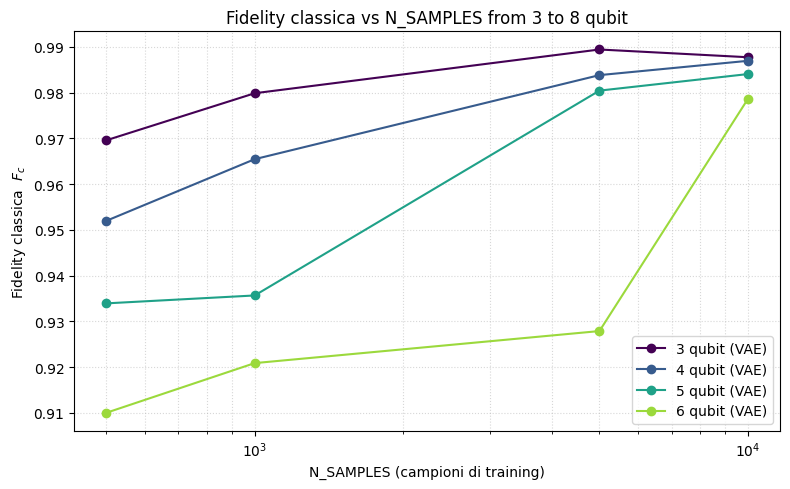

In [20]:
plots.plot_fidelity_vs_samples(results)